# Phase 1: Data Exploration for Total Perspective Vortex
This notebook explores the PhysioNet EEG Motor Movement/Imagery Dataset. 

**Motor Execution vs. Motor Imagery:**
* **Motor Execution (ME):** The subject physically performs a movement (e.g., opening/closing a fist). This generates actual sensory-motor cortex activation.
* **Motor Imagery (MI):** The subject *imagines* performing the movement without any actual muscle activity. This is the core of our BCI pipeline. We aim to detect the Event-Related Desynchronization/Synchronization (ERD/ERS) in the alpha and beta bands that occurs during the *thought* of movement.

In [3]:
import os

In [4]:
print(os.getcwd())

/Users/alex/brige-projects/programing/42/projects/Total-Perspective-Vortex/doc


In [5]:

from misc  import *

## 1.  load the data

In [ ]:

# 1. Load the data
raw = load_eeg_data(SUBJECT_TO_TEST, RUN_TO_TEST)


Loading data from ./data/files/S001/S001R03.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.


## 2. Extract and map events

In [ ]:

# 2. Map the events
events, event_dict, event_descriptions = extract_and_map_events(raw, RUN_TO_TEST)


Mapped Events for Run 3:
  Code 1: Rest (T0)
  Code 2: Opening/closing left fist (T1)
  Code 3: Opening/closing right fist (T2)


In [ ]:
# Example to explore the first 5 events data structure 

events[:5]
# e.g [[time(in seconds), 0, event_code], ...] 

array([[   0,    0,    1],
       [ 672,    0,    3],
       [1328,    0,    1],
       [2000,    0,    2],
       [2656,    0,    1]])

In [ ]:
raw.info

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

## Visualize the raw signals and plot the 3D scalp representation of the electrodes in MNE-Python

In [ ]:
# retreive the 3D EEG data for subject 1, run 4
  # with the standard_1005 montage for better spatial representation
raw_3d_ex = load_eeg_data(1, 4, base_path=BASE_DATA_PATH, montage_type="standard_1005")

Loading data from ./data/files/S001/S001R04.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1005 montage applied.


In [ ]:
raw_3d_ex.info

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

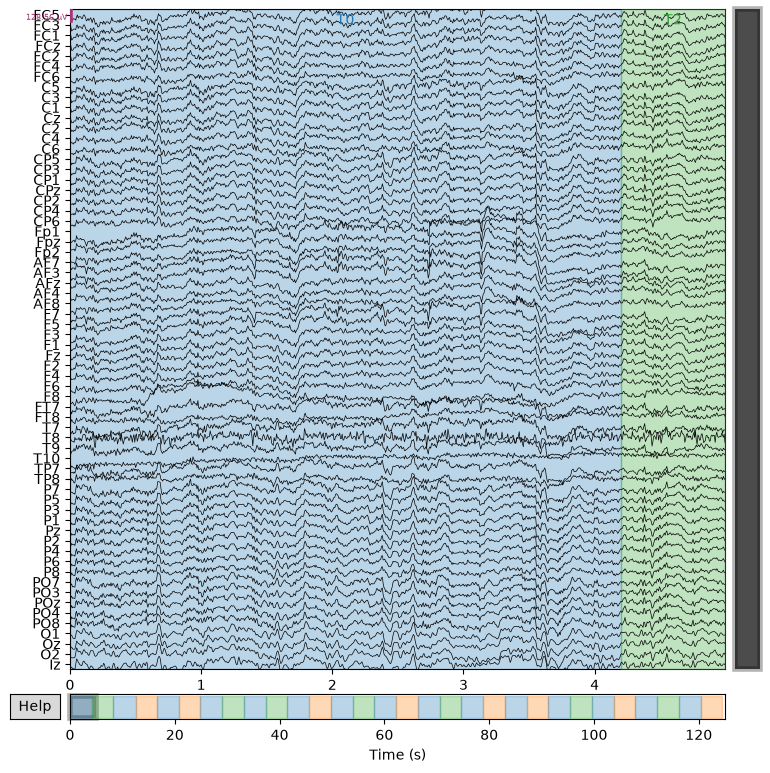

In [ ]:
# Cell 4: Plotting the raw signals
# We specify n_channels=64 to see everything at once.
# duration=5.0 shows 5 seconds of data on the screen at a time.
# scalings='auto' automatically adjusts the vertical scale so the waves don't overlap too much.

fig_signals = raw_3d_ex.plot(
    n_channels=64, # we show all 64 channels at once
    duration=5.0, # it plots the first 5 seconds of data
    scalings="auto",
    title="Raw EEG Signals - All 64 Channels",
)

# Note: If you are using an interactive backend, you can use your arrow keys
# to scroll left and right through the timeline!

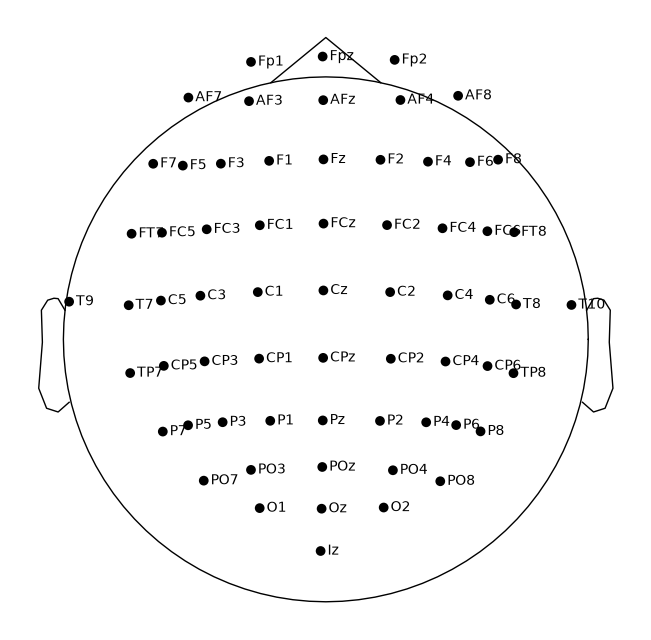

In [ ]:
# Cell 5: Plotting the 3D Scalp representation
# kind='3d' generates the 3D sphere/head model.
# show_names=True prints the channel labels (e.g., 'Cz', 'Pz') next to the dots.
# !ch_type: 'eeg' specifies that we want to visualize EEG channels specifically.
# !show_names: True ensures that the channel names are displayed on the 3D plot.
fig_3d = raw_3d_ex.plot_sensors(kind='topomap', ch_type="eeg", show_names=True)

# Note: In an interactive notebook, you can click and drag this image to rotate the 3D head!

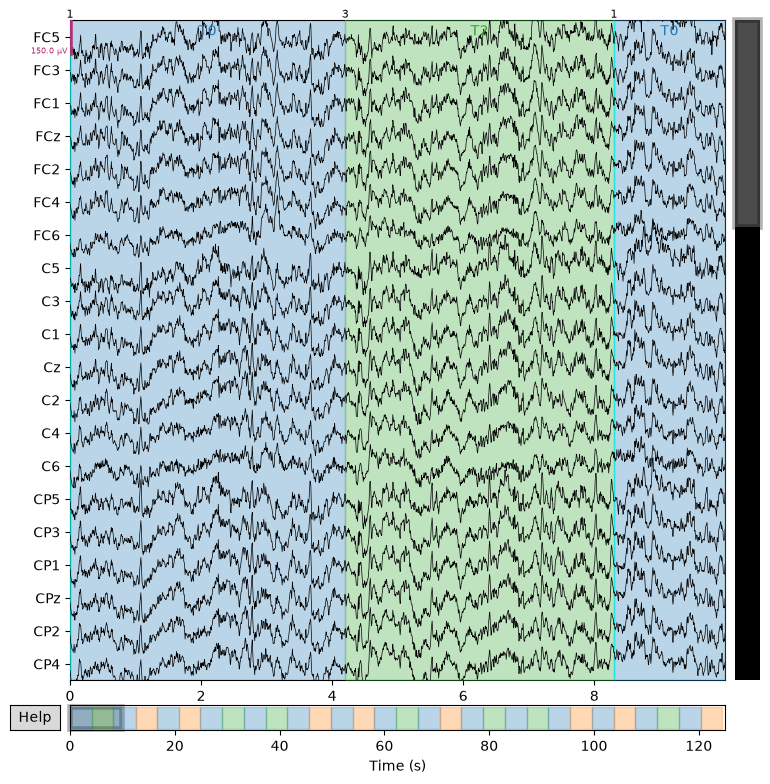

In [ ]:


# 3. Visualize Raw Continuous Signal with Events
# Note: In a Jupyter Notebook, %matplotlib widget or qt can make this fully interactive.
# We set scalings='auto' or a specific microvolt dictionary so signals don't overlap.
fig_raw = raw.plot(
    events=events, 
    start=0, 
    duration=10, # it plots the first 10 seconds of data 
    # n_channels sets how many channels to display at once; adjust for visibility
    n_channels=20, 
    scalings={'eeg': 75e-6}, # Scale to 75 microvolts for better visibility
    title=f"Subject {SUBJECT_TO_TEST} Run {RUN_TO_TEST} - Raw EEG (First 10s)",
    show=True
)


/Users/alex/brige-projects/programing/42/projects/Total-Perspective-Vortex/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


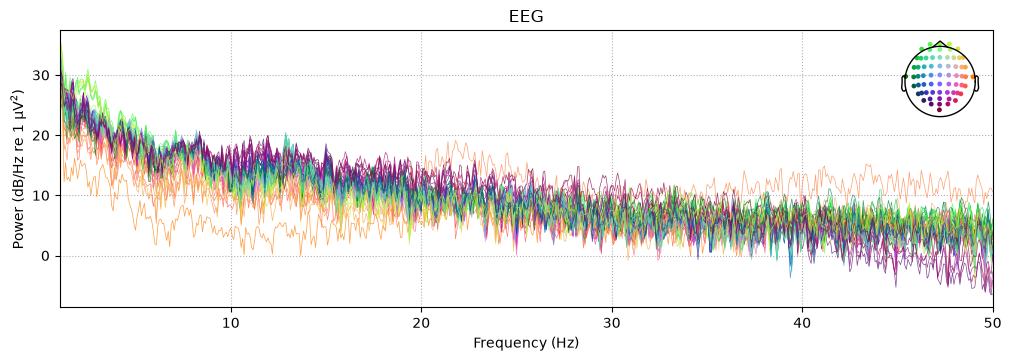

<Figure size 1000x300 with 0 Axes>

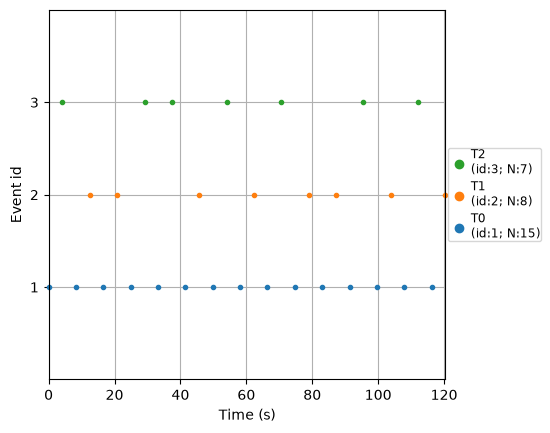

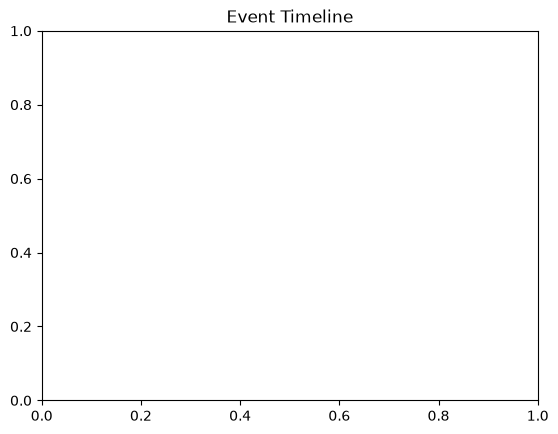

In [ ]:

# 4. Visualize Power Spectral Density (PSD)
# We limit frequencies between 1 Hz and 50 Hz to focus on Alpha (8-13 Hz) and Beta (14-30 Hz)
# This is crucial for feature selection in Phase 1.
# !fmin:  means the minimum frequency to include in the PSD calculation
# ! fmax:  means the maximum frequency to include in the PSD calculation
fig_psd = raw.compute_psd(fmin=1.0, fmax=50.0).plot(
    # picks means which channels to include in the PSD calculation. 
        # 'eeg' includes all EEG channels.
    picks='eeg', 
    # exclude means which channels to exclude from the PSD calculation. 
        # 'bads' includes all channels marked as bad in the raw.info['bads'] list.
    exclude='bads',
    show=True
)

#===============================================================================
#                 event timing
#===============================================================================
# Add supplementary static visualization of event timing using Matplotlib
plt.figure(figsize=(10, 3))
# viz.plot_events is a static visualization of events over time,
#  useful for quick inspection.
mne.viz.plot_events(
    # events: The array of events extracted from the raw data.
        # e.g
    events, 
    sfreq=raw.info['sfreq'], 
    first_samp=raw.first_samp, 
    event_id=event_dict
)
plt.title("Event Timeline")
plt.show()